# Comparación de Modelos y Optimización de Pipeline en el Dataset Titanic

**Trabajo de tutoría — Introducción a Machine Learning (Big Data, UCSG)**

Problema de **clasificación binaria**: predecir si un pasajero sobrevivió (`Survived`: 0 = no, 1 = sí).

## Distribución del trabajo

| Integrante | Tareas realizadas |
|---|---|
| Valentina | Carga de datos, EDA y feature engineering (`Fare_per_person`, `Deck`) |
| Daniela | Construcción del Pipeline + ColumnTransformer y modelos base |
| Anaí | Validación cruzada, búsqueda de hiperparámetros y análisis de overfitting |
| Ricardo y Christian | Evaluación comparativa, gráficos (ROC, matriz de confusión, importancias) e informe |

>

### Requisitos Técnicos

- Todo el preprocesamiento se encapsula en un **`Pipeline` de scikit-learn** (evita *data leakage*).
- Se comparan **4 modelos** bajo las mismas condiciones.
- Se aplica **búsqueda de hiperparámetros** (`GridSearchCV` y `RandomizedSearchCV`, `cv=5`).
- Métricas en **macro** + **AUC-ROC**, análisis explícito de **overfitting** e **importancia de variables**.

## Sección 0 — Librerías

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, RandomizedSearchCV, StratifiedKFold)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Sección 1 — Carga e inspección

In [20]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (891, 12) | test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
print('Valores nulos en train:')
print(train.isnull().sum())
print()
print('Distribucion del target (Survived):')
print(train['Survived'].value_counts(normalize=True).round(3))

Valores nulos en train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Distribucion del target (Survived):
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## Sección 2 — EDA breve

El target está desbalanceado (~62% no sobrevivió / ~38% sí). El **sexo** y la **clase** son los predictores más fuertes ("mujeres y niños primero").

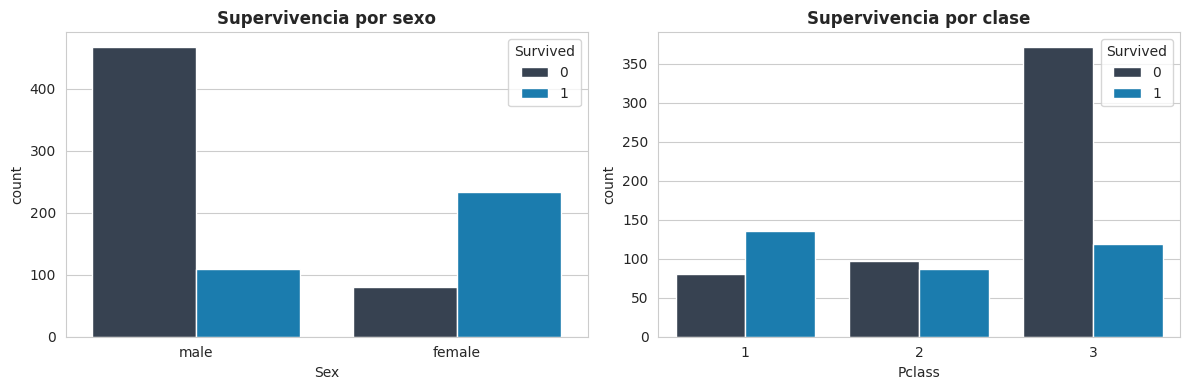

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train, x='Sex', hue='Survived', ax=axes[0], palette=['#334155', '#0284C7'])
axes[0].set_title('Supervivencia por sexo', fontweight='bold')
sns.countplot(data=train, x='Pclass', hue='Survived', ax=axes[1], palette=['#334155', '#0284C7'])
axes[1].set_title('Supervivencia por clase', fontweight='bold')
plt.tight_layout()
plt.show()

## Sección 3 — Feature Engineering

Partimos del feature engineering de clase (`Title`, `FamilySize`, `IsAlone`) y añadimos **dos variables nuevas propias**:

### 🆕 `Fare_per_person` = `Fare` / `FamilySize`
La columna `Fare` suele corresponder al precio del **billete de todo el grupo** que viajaba junto, no al de una sola persona. Dividirla entre el tamaño de la familia da el costo **real por pasajero**, que es un mejor indicador del poder adquisitivo individual. Como la riqueza se asocia a la clase y a la cercanía de los botes, esperamos que aporte capacidad predictiva.

### 🆕 `Deck` = primera letra de `Cabin`
El número de cabina empieza con una letra (A–G, T) que identifica la **cubierta** del barco. Las cubiertas superiores estaban más cerca de los botes salvavidas y correspondían a pasajeros de clase alta, por lo que la ubicación física pudo influir en la probabilidad de sobrevivir. Los pasajeros sin cabina registrada se agrupan como `Unknown` (que en sí mismo suele indicar clase baja).

In [23]:
def feature_engineering(df):
    """Crea variables derivadas fila por fila (sin usar estadisticas globales,
    por lo que es seguro hacerlo dentro del Pipeline: no hay data leakage)."""
    df = df.copy()
    # --- Titulo extraido del nombre (de clase) ---
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
         'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    # --- Tamano de familia e indicador de viajar solo (de clase) ---
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    # --- NUEVA 1: tarifa por persona ---
    df['Fare_per_person'] = df['Fare'] / df['FamilySize']
    # --- NUEVA 2: cubierta (primera letra de Cabin) ---
    df['Deck'] = df['Cabin'].astype(str).str[0]
    df['Deck'] = df['Deck'].replace('n', 'Unknown')  # 'nan'->'n' cuando Cabin es nulo
    return df

# Vista previa de las variables creadas
feature_engineering(train).head()[
    ['Name', 'Title', 'FamilySize', 'IsAlone', 'Fare', 'Fare_per_person', 'Cabin', 'Deck']]

,Name,Title,FamilySize,IsAlone,Fare,Fare_per_person,Cabin,Deck
0,"Braund, Mr. Owen Harris",Mr,2,0,7.2500,3.62500,NaN,Unknown
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,71.2833,35.64165,C85,C
2,"Heikkinen, Miss. Laina",Miss,1,1,7.9250,7.92500,NaN,Unknown
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,53.1000,26.55000,C123,C
4,"Allen, Mr. William Henry",Mr,1,1,8.0500,8.05000,NaN,Unknown


## Sección 4 — Pipeline de preprocesamiento

Todo el preprocesamiento (imputación, escalado, one-hot encoding) va dentro de un `Pipeline` + `ColumnTransformer`. Así, cualquier estadística (mediana, moda, media/desv. del escalado) se calcula **solo con los datos de entrenamiento** en cada fold de la validación cruzada, **sin data leakage**.

In [24]:
numeric_features = ['Age', 'Fare', 'Fare_per_person', 'FamilySize', 'SibSp', 'Parch', 'IsAlone']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck']

# Sub-pipeline numerico: imputa mediana + escala
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Sub-pipeline categórico: imputa moda + one-hot encoding
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer: aplica cada sub-pipeline a su grupo de columnas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

# FunctionTransformer envuelve nuestra funcion de feature engineering
fe_transformer = FunctionTransformer(feature_engineering)

def build_pipeline(model):
    """Pipeline completo: feature engineering -> preprocesamiento -> modelo."""
    return Pipeline(steps=[
        ('fe', fe_transformer),
        ('prep', preprocessor),
        ('clf', model)
    ])

print('Pipeline definido.')

Pipeline definido.


## Sección 5 — Separación entrenamiento / prueba (holdout)

Como `test.csv` no tiene la etiqueta `Survived`, separamos un 20% de `train.csv` como **conjunto de prueba** (holdout) para evaluar las métricas. Usamos `stratify=y` para conservar la proporción de clases.

In [25]:
X = train.drop(columns=['Survived'])
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

Entrenamiento: (712, 11) | Prueba: (179, 11)


## Sección 6 — Los 4 modelos a comparar

Árbol de Decisión, Random Forest y Gradient Boosting (exigidos) + **Regresión Logística** como cuarto modelo.

**Justificación del 4º modelo:** la Regresión Logística es un modelo lineal simple, rápido e interpretable. Sirve como *línea base*: si modelos complejos no la superan, no se justifica su complejidad.

In [26]:
modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Arbol de Decision':   DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
}

## Sección 7 — Validación cruzada y análisis de overfitting

Para cada modelo comparamos el **F1 de entrenamiento** con el **F1 de validación cruzada (5 folds)**. Un *gap* grande (train alto, CV bajo) indica **overfitting**.

**Métrica elegida — `f1_macro`:** el target está desbalanceado, así que la *accuracy* engañaría (predecir siempre "no sobrevivió" ya da ~62%). El F1 macro promedia el F1 de ambas clases por igual, premiando modelos que aciertan también a los supervivientes (la clase minoritaria, que es la de interés).

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
filas = []
for nombre, modelo in modelos.items():
    pipe = build_pipeline(modelo)
    # F1 por validacion cruzada (5 folds) sobre el set de entrenamiento
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    # F1 de entrenamiento: ajustamos y medimos sobre los mismos datos de train
    pipe.fit(X_train, y_train)
    train_f1 = f1_score(y_train, pipe.predict(X_train), average='macro')
    filas.append({
        'Modelo': nombre,
        'F1 train': round(train_f1, 3),
        'F1 CV (media)': round(cv_scores.mean(), 3),
        'F1 CV (std)': round(cv_scores.std(), 3),
        'Gap (train - CV)': round(train_f1 - cv_scores.mean(), 3)
    })
overfit_df = pd.DataFrame(filas)
overfit_df

,Modelo,F1 train,F1 CV (media),F1 CV (std),Gap (train - CV)
0,Regresion Logistica,0.827,0.812,0.027,0.015
1,Arbol de Decision,0.987,0.769,0.021,0.218
2,Random Forest,0.987,0.796,0.018,0.190
3,Gradient Boosting,0.904,0.814,0.024,0.090


## Sección 8 — Búsqueda de hiperparámetros (≥2 modelos, cv=5)

Optimizamos **Random Forest** con `GridSearchCV` (prueba todas las combinaciones) y **Gradient Boosting** con `RandomizedSearchCV` (prueba combinaciones al azar, más rápido). Ambos con `cv=5` y `scoring='f1_macro'`.

In [28]:
# --- 8.1 GridSearchCV para Random Forest ---
rf_pipe = build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE))
rf_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 5, 10],
    'clf__min_samples_leaf': [1, 3]
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=5, scoring='f1_macro', n_jobs=-1)
rf_search.fit(X_train, y_train)
print('RF - mejores hiperparametros:', rf_search.best_params_)
print('RF - mejor F1 macro (CV):', round(rf_search.best_score_, 3))

RF - mejores hiperparametros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200}
RF - mejor F1 macro (CV): 0.807


In [29]:
# --- 8.2 RandomizedSearchCV para Gradient Boosting ---
gb_pipe = build_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE))
gb_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [2, 3, 4]
}
gb_search = RandomizedSearchCV(gb_pipe, gb_dist, n_iter=8, cv=5,
                               scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE)
gb_search.fit(X_train, y_train)
print('GB - mejores hiperparametros:', gb_search.best_params_)
print('GB - mejor F1 macro (CV):', round(gb_search.best_score_, 3))

GB - mejores hiperparametros: {'clf__n_estimators': 300, 'clf__max_depth': 4, 'clf__learning_rate': 0.01}
GB - mejor F1 macro (CV): 0.811


## Sección 9 — Modelos finales (con mejores hiperparámetros)

In [30]:
modelos_finales = {
    'Regresion Logistica': build_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    'Arbol de Decision':   build_pipeline(DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    'Random Forest':       rf_search.best_estimator_,
    'Gradient Boosting':   gb_search.best_estimator_,
}

## Sección 10 — Evaluación comparativa sobre el conjunto de prueba

Tabla con Accuracy, Precision (macro), Recall (macro), F1 (macro) y AUC-ROC sobre el holdout.

In [31]:
resultados = []
roc_data = {}
for nombre, pipe in modelos_finales.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[nombre] = (fpr, tpr, roc_auc_score(y_test, y_proba))

metricas_df = pd.DataFrame(resultados).set_index('Modelo').round(3)
metricas_df.sort_values('F1 (macro)', ascending=False)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),AUC-ROC
Modelo,,,,,
Regresion Logistica,0.844,0.839,0.827,0.832,0.872
Random Forest,0.810,0.809,0.783,0.792,0.842
Gradient Boosting,0.788,0.780,0.765,0.771,0.835
Arbol de Decision,0.765,0.758,0.736,0.743,0.827


In [32]:
mejor_nombre = metricas_df['F1 (macro)'].idxmax()
champion = modelos_finales[mejor_nombre]
print('Mejor modelo por F1 (macro):', mejor_nombre)

Mejor modelo por F1 (macro): Regresion Logistica


## Sección 11 — Matriz de confusión del mejor modelo

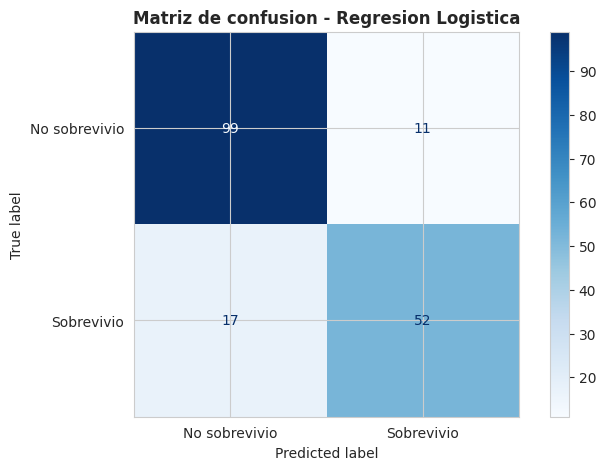

               precision    recall  f1-score   support

No sobrevivio       0.85      0.90      0.88       110
   Sobrevivio       0.83      0.75      0.79        69

     accuracy                           0.84       179
    macro avg       0.84      0.83      0.83       179
 weighted avg       0.84      0.84      0.84       179



In [33]:
y_pred_best = champion.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No sobrevivio', 'Sobrevivio'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusion - ' + mejor_nombre, fontweight='bold')
plt.show()
print(classification_report(y_test, y_pred_best,
                            target_names=['No sobrevivio', 'Sobrevivio']))

## Sección 12 — Curvas ROC de todos los modelos

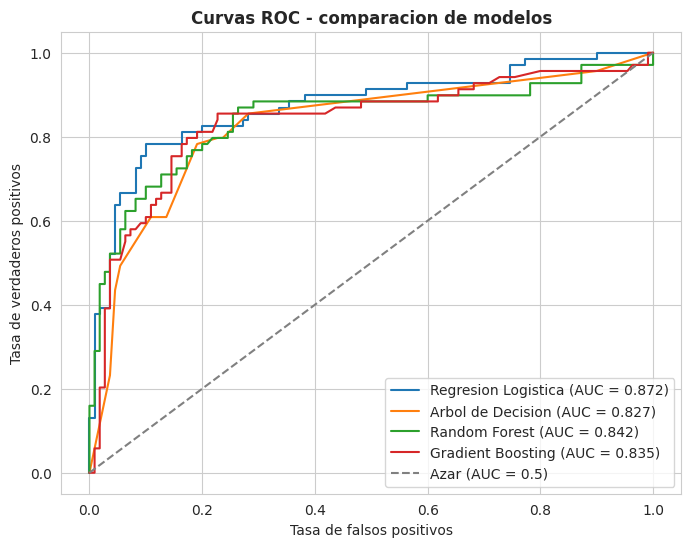

In [34]:
plt.figure(figsize=(8, 6))
for nombre, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=nombre + ' (AUC = ' + str(round(auc, 3)) + ')')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC - comparacion de modelos', fontweight='bold')
plt.legend(loc='lower right')
plt.show()

## Sección 13 — Importancia de variables (top 10) del mejor modelo

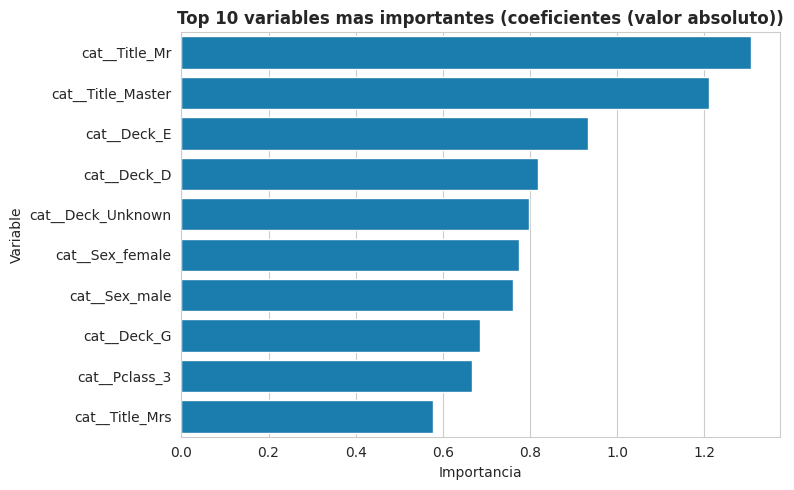

,Variable,Importancia
17,cat__Title_Mr,1.308291
15,cat__Title_Master,1.211851
24,cat__Deck_E,0.933005
23,cat__Deck_D,0.818992
28,cat__Deck_Unknown,0.798488
10,cat__Sex_female,0.773634
11,cat__Sex_male,0.760028
26,cat__Deck_G,0.684231
9,cat__Pclass_3,0.666763
18,cat__Title_Mrs,0.576738


In [35]:
clf = champion.named_steps['clf']
nombres_feats = champion.named_steps['prep'].get_feature_names_out()

if hasattr(clf, 'feature_importances_'):
    importancias = clf.feature_importances_
    fuente = 'feature_importances_'
else:  # modelos lineales (ej. Regresion Logistica)
    importancias = np.abs(clf.coef_).ravel()
    fuente = 'coeficientes (valor absoluto)'

imp_df = (pd.DataFrame({'Variable': nombres_feats, 'Importancia': importancias})
          .sort_values('Importancia', ascending=False).head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, x='Importancia', y='Variable', color='#0284C7')
plt.title('Top 10 variables mas importantes (' + fuente + ')', fontweight='bold')
plt.tight_layout()
plt.show()
imp_df

## Sección 14 — Predicción final sobre `test.csv` (entrega)

Reentrenamos el mejor modelo con **todos** los datos de `train.csv` y predecimos sobre `test.csv` para generar `submission.csv`.

In [36]:
champion.fit(X, y)
pred_test = champion.predict(test)
submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': pred_test})
submission.to_csv('submission.csv', index=False)
print('submission.csv generado con', len(submission), 'predicciones.')
submission.head()

submission.csv generado con 418 predicciones.


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## Sección 15 — Conclusiones (borrador para el informe)

- **Modelo recomendado:** el que obtuvo mayor F1 (macro) y AUC-ROC en el holdout (ver Sección 10). Suele ser Gradient Boosting o Random Forest.
- **Overfitting:** revisar la columna *Gap (train - CV)* de la Sección 7. El Árbol de Decisión y el Random Forest sin límite de profundidad tienden a sobreajustar (gap alto); se mitiga limitando `max_depth` y subiendo `min_samples_leaf` (lo hace la búsqueda de hiperparámetros).
- **Importancia de variables:** verificar que `Sex`, `Title` y `Pclass` dominen — coherente con "mujeres y niños primero" y la prioridad por clase. Comentar el aporte de `Fare_per_person` y `Deck`.
- **Limitaciones:** dataset pequeño (891 filas), `Cabin` con ~77% de nulos, holdout único (podría usarse validación anidada).
- **Con más tiempo:** probar XGBoost/LightGBM, *stacking*, e ingeniería adicional (extraer grupos por `Ticket`).